In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [2]:
class ParallelGraphState(TypedDict):
    first: float
    second: float
    
    sum: float
    mult: float
    diff: float
    total: float



In [3]:
def calculate_sum(state: ParallelGraphState):
    sum = state["first"] + state["second"]

    # this won't work with paraller execution 
    # in this condition the langgraph will be getting confused, coz 
    # which state is update by which node at the time of parallel execution 
    #
    # state["sum"] = sum
    # return state

    # in parallel graphs we need to return only the state variable which we are updating
    return {"sum": sum}

def calculate_mult(state: ParallelGraphState):
    mult = state["first"] * state["second"]
    return {"mult" : mult}

def calculate_diff(state: ParallelGraphState):
    diff = state["first"] - state["second"]
    return {"diff": diff}


def combined_sum(state: ParallelGraphState):
    total = state["sum"] + state["mult"] + state["diff"]
    return {"total": total}


In [4]:
graph = StateGraph(ParallelGraphState)


# add nodes

graph.add_node("calculate_sum", calculate_sum)
graph.add_node("calculate_mult", calculate_mult)
graph.add_node("calculate_diff", calculate_diff)
graph.add_node("combined_sum", combined_sum)

# add edges

graph.add_edge(START, "calculate_sum")
graph.add_edge(START, "calculate_mult")
graph.add_edge(START, "calculate_diff")

graph.add_edge("calculate_sum", "combined_sum")
graph.add_edge("calculate_mult", "combined_sum")
graph.add_edge("calculate_diff", "combined_sum")

graph.add_edge("combined_sum", END)


# compile

workflow = graph.compile()


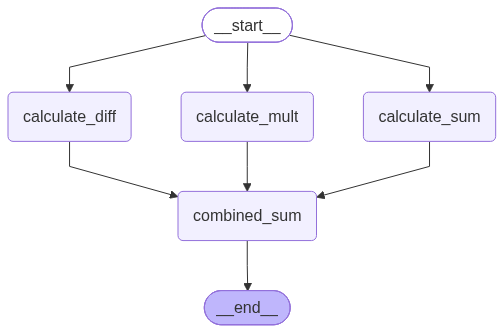

In [5]:
workflow

In [6]:
initial_state = {"first": 4, "second": 3}

output = workflow.invoke(initial_state)

print(output)

{'first': 4, 'second': 3, 'sum': 7, 'mult': 12, 'diff': 1, 'total': 20}
